In [1]:
import torch

# Limit to fraction of total GPU memory
torch.cuda.set_per_process_memory_fraction(0.5, device=0)

## Attributions

### Load data

Load metadata frst

In [2]:
# Path to test data
test_data_dir = '/home/elek/sds/sd17d003/Anamaria/splicevo/data_02/splits_full_50kb/mouse_human/test/'

import os
import pandas as pd

# First load metadat
meta_csv_fn = os.path.join(test_data_dir, 'metadata.csv')
metadata_csv = pd.read_csv(meta_csv_fn)
print(metadata_csv.head())

import json

meta_fn = os.path.join(test_data_dir, 'metadata.json')
with open(meta_fn) as f:
    metadata = json.load(f)

print("\nWindow size", metadata['window_size'])
print("Context size", metadata['context_size'])
species_conds = metadata['species_condition_mapping']

for org, cond in species_conds.items():
    print(f"Conditions for {org}:")
    print([metadata['usage_conditions'][cond_idx] for cond_idx in cond])

   chromosome    gene_id     genome_id  n_acceptor_sites  n_donor_sites  \
0          11  hum.10118  human_GRCh37                 0              1   
1          11  hum.10118  human_GRCh37                 3              4   
2          11  hum.10118  human_GRCh37                10             10   
3          11  hum.10118  human_GRCh37                10             10   
4          11  hum.10118  human_GRCh37                14             12   

  strand  window_end  window_start  species_id  
0      +    26405019      26353869           0  
1      +    26507319      26456169           0  
2      +    26558469      26507319           0  
3      +    26609619      26558469           0  
4      +    26660769      26609619           0  

Window size 51150
Context size 500
Conditions for human:
['Brain_1', 'Brain_4', 'Brain_5', 'Brain_7', 'Brain_9', 'Brain_10', 'Brain_14', 'Cerebellum_2', 'Cerebellum_5', 'Cerebellum_8', 'Cerebellum_9', 'Cerebellum_15', 'Heart_1', 'Heart_3', 'Heart_5', 'He

Load and create dataset

In [3]:
%reload_ext autoreload
%autoreload 2
from alphagenome_pytorch import SpliceDataset

# Calculate target length (must be divisible by 128 for efficient batching)
target_length = 49152 # 10240 49152
print(f"Target sequence length: {target_length}")

# Calculate max donor/acceptor sites for junctions
max_donor = metadata_csv['n_donor_sites'].max()
max_acceptor = metadata_csv['n_acceptor_sites'].max()
max_sites = max(max_donor, max_acceptor)
max_sites = (max_sites // 10) * 10 
print(f"Max sites: {max_sites}")
max_donor_sites = max_sites
max_acceptor_sites = max_sites

# Species
species_mapping = {
    'human': 0,
    'mouse': 1
}

test_dataset = SpliceDataset(
    data_dir=test_data_dir,
    target_length=target_length,
    max_donor_sites=max_donor_sites,
    max_acceptor_sites=max_acceptor_sites,
    species_mapping=species_mapping
)

2026-03-04 11:45:34.670287: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 11:45:34.711795: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Target sequence length: 49152
Max sites: 5540
Loaded dataset from /home/elek/sds/sd17d003/Anamaria/splicevo/data_02/splits_full_50kb/mouse_human/test/


In [4]:
next(iter(test_dataset))

{'dna': tensor([1, 1, 1,  ..., 0, 0, 3]),
 'organism_index': tensor(0),
 'splice_donor_idx': tensor([0, 0, 0,  ..., 0, 0, 0]),
 'splice_acceptor_idx': tensor([0, 0, 0,  ..., 0, 0, 0]),
 'num_donors': tensor(0),
 'num_acceptors': tensor(0),
 'splice_labels': tensor([4, 4, 4,  ..., 4, 4, 4]),
 'splice_usage_target': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 'conditions_mask': tensor([ 0,  3,  4,  6,  8,  9, 13, 14, 16, 19, 20, 26, 27, 29, 31, 33, 34, 35,
         36, 38, 41, 43, 44, 45, 47, 48, 49, 50, 54, 55, 56, 57, 58, 60, 61, 62,
         63, 64, 65, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 78, 83, 84, 85, 86,
         87, 88, 89, 90, 91, 92, 96, 97]),
 'gene_region': tensor([    0, 49152])}

Subset _n_ sequences

In [5]:
import torch
import numpy as np

np.random.seed(1901)

# Subset n random sequences per species for attribution analysis
n_per_species = 1
n = n_per_species * len(species_mapping)
rand_indx = []
for species in species_mapping.keys():
    species_id = metadata['species_mapping'][species]
    species_idx = metadata_csv[metadata_csv['species_id'] == species_id].index.tolist()
    print(f"{len(species_idx)} samples available for {species}")
    rand_indx.extend(np.random.choice(species_idx, n_per_species, replace=False))

# Alternativelly select specific sequences
rand_indx = [819, 1604, 2256] # Brain up sites in mouse


organism_index = []
for i in rand_indx:
    organism_index.append(test_dataset[i]['organism_index'])

organism_index = torch.tensor(organism_index)
print(organism_index.shape)
organism_index

497 samples available for human
3200 samples available for mouse
torch.Size([3])


tensor([1, 1, 1])

Organism that the first _n_ sequences belong to.

In [6]:
dna = []
for i in rand_indx:
    dna.append(test_dataset[i]['dna'])
dna = torch.stack(dna)
print(dna.shape)
dna

torch.Size([3, 49152])


tensor([[0, 2, 3,  ..., 0, 0, 0],
        [1, 1, 0,  ..., 2, 2, 0],
        [0, 0, 0,  ..., 3, 0, 2]])

Splice labels

In [7]:
splice_labels = []
for i in rand_indx:
    splice_labels.append(test_dataset[i]['splice_labels'])
splice_labels = torch.stack(splice_labels)
print(splice_labels.shape)
print(splice_labels)

# Count splice sites in the batch
for i in range(splice_labels.shape[0]):
    donor_plus_count = (splice_labels[i] == 0).sum().item()
    acceptor_plus_count = (splice_labels[i] == 1).sum().item()
    donor_minus_count = (splice_labels[i] == 2).sum().item()
    acceptor_minus_count = (splice_labels[i] == 3).sum().item()
    print(f"Sample {i}: ")
    print(f"  {donor_plus_count} donor sites: {(splice_labels[i] == 0).nonzero(as_tuple=True)[0].numpy()}")
    print(f"  {acceptor_plus_count} acceptor sites: {(splice_labels[i] == 1).nonzero(as_tuple=True)[0].numpy()}")
    print(f"  {donor_minus_count} donor minus sites: {(splice_labels[i] == 2).nonzero(as_tuple=True)[0].numpy()}")
    print(f"  {acceptor_minus_count} acceptor minus sites: {(splice_labels[i] == 3).nonzero(as_tuple=True)[0].numpy()}")

torch.Size([3, 49152])
tensor([[4, 4, 4,  ..., 4, 4, 4],
        [4, 4, 4,  ..., 4, 4, 4],
        [4, 4, 4,  ..., 4, 4, 4]])
Sample 0: 
  0 donor sites: []
  0 acceptor sites: []
  16 donor minus sites: [17988 18348 18596 18642 18900 19370 19772 20844 21515 22577 22873 27142
 27525 27550 27572 31432]
  13 acceptor minus sites: [17716 18228 18362 18742 18989 19393 20906 21526 21893 22669 23006 27270
 27691]
Sample 1: 
  0 donor sites: []
  0 acceptor sites: []
  7 donor minus sites: [19246 19510 19512 20045 20956 22564 24929]
  6 acceptor minus sites: [15020 19365 19678 21096 22770 25070]
Sample 2: 
  8 donor sites: [15700 18358 20421 21303 26635 28898 29983 31455]
  7 acceptor sites: [18213 20273 21244 26534 28872 29942 31407]
  0 donor minus sites: []
  0 acceptor minus sites: []


### Load fine-tuned model

In [8]:
import os
import yaml
import torch
from alphagenome_pytorch import AlphaGenome, AlphaGenomeConfig

use_finetuned_model = True
checkpoint_path = 'auto'  # Set to 'auto' to load from config output_dir/model_name.pt
checkpoint_path = "/home/elek/sds/sd17d003/Anamaria/alphagenome_pytorch/02/full_50kb/mouse_human/finetune_heads.pt"

if use_finetuned_model:

    # Load config
    config_file = '../configs/splice_finetune_full_50kb.yaml'
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)

    # Get model architecture parameters (matching training)
    default_cfg = AlphaGenomeConfig()
    model_cfg = config.get('model', {})
    dims = tuple(model_cfg.get('dims', default_cfg.dims))
    basepairs = model_cfg.get('basepairs', default_cfg.basepairs)
    dna_embed_width = model_cfg.get('dna_embed_width', default_cfg.dna_embed_width)
    num_organisms = model_cfg.get('num_organisms', default_cfg.num_organisms)
    transformer_kwargs = model_cfg.get('transformer_kwargs', default_cfg.transformer_kwargs)
    heads_cfg = model_cfg.get('heads_cfg')

    # Create model with same architecture as training
    model = AlphaGenome(dims, basepairs, dna_embed_width, num_organisms, transformer_kwargs)

    # Add heads with same config as training
    for organism, head_cfg in heads_cfg.items():
        model.add_heads(organism=organism, **head_cfg)

    # Load the checkpoint
    if checkpoint_path == 'auto':
        output_dir = config.get('output_dir', './outputs')
        model_name = config.get('model_name', 'alphagenome_finetuned')
        checkpoint_path = os.path.join(output_dir, f'{model_name}.pt')
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)

    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'])

    # Set to eval mode
    model.eval()

    print(f"Model loaded from {checkpoint_path}")
    print(f"Trained for {checkpoint['epoch']} epochs")

/home/elek/miniforge3/envs/alphagenome_pytorch/lib/python3.12/site-packages/torch/nn/modules/linear.py:124: UserWarning: Initializing zero-element tensors is a no-op
  init.kaiming_uniform_(self.weight, a=math.sqrt(5))


Model loaded from /home/elek/sds/sd17d003/Anamaria/alphagenome_pytorch/02/full_50kb/mouse_human/finetune_heads.pt
Trained for 20 epochs


### Calculate attributions

In [9]:
# Sequence must be the float one-hot tensor, not integer tokens.
print(dna.shape)
print(dna)

# Convert integer tokens to ohe-hot encoding
onehot_tensor = torch.zeros(dna.size(0), dna.size(1), 4)  # [B, S, 4]
onehot_tensor.scatter_(2, dna.unsqueeze(2), 1)
print(onehot_tensor.shape)
print(onehot_tensor)

torch.Size([3, 49152])
tensor([[0, 2, 3,  ..., 0, 0, 0],
        [1, 1, 0,  ..., 2, 2, 0],
        [0, 0, 0,  ..., 3, 0, 2]])
torch.Size([3, 49152, 4])
tensor([[[1., 0., 0., 0.],
         [0., 0., 1., 0.],
         [0., 0., 0., 1.],
         ...,
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.]],

        [[0., 1., 0., 0.],
         [0., 1., 0., 0.],
         [1., 0., 0., 0.],
         ...,
         [0., 0., 1., 0.],
         [0., 0., 1., 0.],
         [1., 0., 0., 0.]],

        [[1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         ...,
         [0., 0., 0., 1.],
         [1., 0., 0., 0.],
         [0., 0., 1., 0.]]])


In [10]:
import os
os.makedirs("plots", exist_ok=True)

#### Splice site classification attributions

In [75]:
%reload_ext autoreload
%autoreload 2
from alphagenome_pytorch import AlphaGenome

class_labels = {0: 'donor+', 1: 'acceptor+', 2: 'donor-', 3: 'acceptor-', 4: 'no_ss'}
class_colors = {0: '#ff7f00', 1: '#33a02c', 2: '#fdbf6f', 3: '#b2df8a', 4: '#1f78b4'}

# batch index
b = 2
genome_id = metadata_csv.loc[rand_indx[b], 'genome_id']
chr = metadata_csv.loc[rand_indx[b], 'chromosome']
print(f"Sample {rand_indx[b]}: Genome {genome_id}, Chromosome {chr}")

# Splice site type
k = 1
site_positions = (splice_labels[b] == k).nonzero(as_tuple=True)[0]
print(f"Positions of {class_labels[k]} sites: {site_positions.numpy()}")

# Selected splice site
p = site_positions[4].item()  # Select one site for attribution

# Compute attributions
grads, preds = model.compute_integrated_gradients(
    seq=dna,
    organism_index=organism_index,
    organism=org,
    head_name='splice_sites_classification', # splice_sites_classification splice_sites_usage
    output_position=p,
    output_index=k,
    return_predictions=True
)

Sample 2256: Genome mouse_GRCm38, Chromosome 2
Positions of acceptor+ sites: [18213 20273 21244 26534 28872 29942 31407]
Bins around site 28872: [23872 24372 24872 25372 25872 26372 26872 27372 27872 28372 28872 29372
 29872 30372 30872 31372 31872 32372 32872 33372]


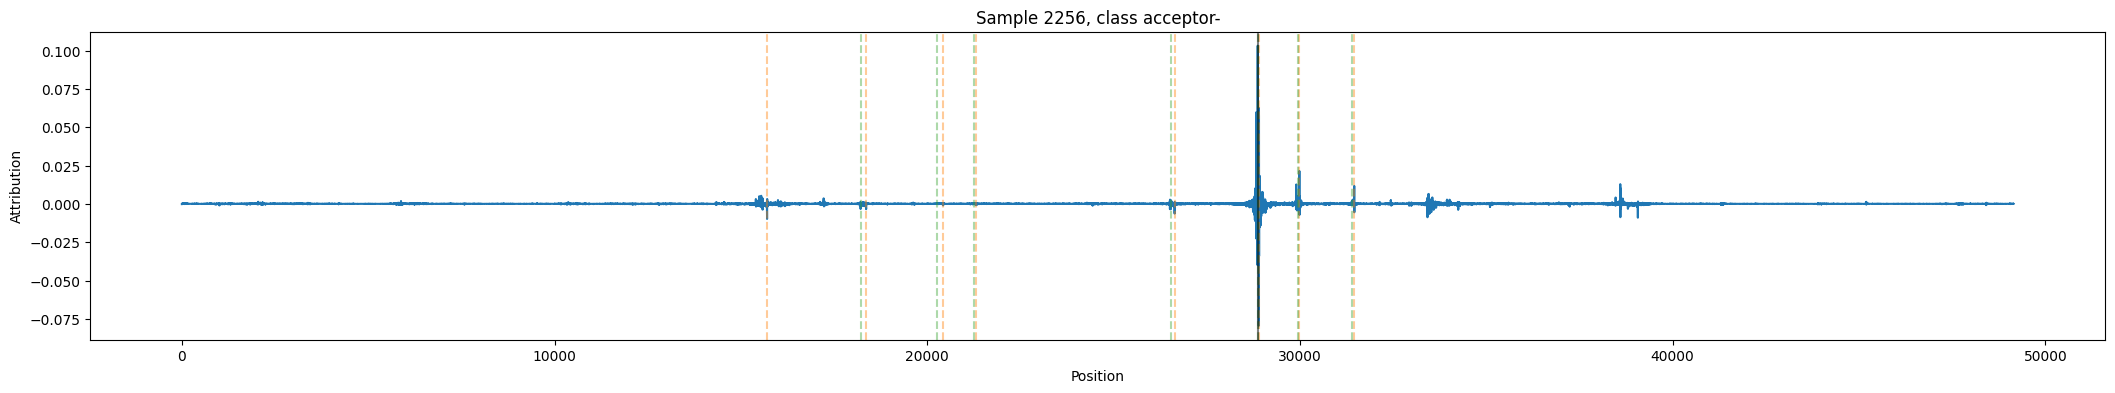

In [94]:
# Get gradients for the sequence in the batch
grads_b = grads[b]

# Multiply gradients by input to get importance scores
grads_b_importance = grads_b * onehot_tensor[b]
grads_b_max = grads_b_importance.sum(dim=1)  # Sum importance across A,C,G,T to get single importance score per position

# Plot max gradients across the sequence
import matplotlib.pyplot as plt
plt.figure(figsize=(26, 4))
plt.plot(grads_b_max.numpy())

# Add vertical lines at the splice site positions colorcoded by class
for k in range(4):
    site_positions = (splice_labels[b] == k).nonzero(as_tuple=True)[0]
    for pos in site_positions:
        plt.axvline(x=pos.item(), color=class_colors[k], linestyle='--', alpha=0.4)

# Add vertical line at the specific site p
plt.axvline(x=p, color='black', linestyle='-', alpha=0.5, label='Selected site')

# Show plot
plt.title(f"Sample {rand_indx[b]}, class {class_labels[k]}")
plt.xlabel("Position")
plt.ylabel("Attribution")
plt.show()

In [76]:
# Make windows around the site for attribution plotting
w = 500
upstream_bins = torch.arange(p - w * 35, p, step=w)
downstream_bins = torch.arange(p + w, p + w * 35, step=w)
bins = torch.cat([upstream_bins, torch.tensor([p]), downstream_bins])
print(f"Bins around site: {bins.numpy()}")


Bins around site: [11372 11872 12372 12872 13372 13872 14372 14872 15372 15872 16372 16872
 17372 17872 18372 18872 19372 19872 20372 20872 21372 21872 22372 22872
 23372 23872 24372 24872 25372 25872 26372 26872 27372 27872 28372 28872
 29372 29872 30372 30872 31372 31872 32372 32872 33372 33872 34372 34872
 35372 35872 36372 36872 37372 37872 38372 38872 39372 39872 40372 40872
 41372 41872 42372 42872 43372 43872 44372 44872 45372 45872]


In [77]:
%reload_ext autoreload
%autoreload 2
from alphagenome_pytorch import AlphaGenome

# Plot attributions
model.plot_sequence_logo(
    sequence=onehot_tensor,
    gradients=grads,
    batch_idx=b,
    positions=bins,  # one subplot per site
    splice_labels=splice_labels, # pass the full [B, S] label tensor
    window=w//2, # bp around each site
    mask_to_sequence=True,
    sharey=True,
    ylim=(-0.05, 0.05),
    title=f"{genome_id} {chr}:{p} {class_labels[k]}",
    save_path=f"plots/attr_classification_batch_{genome_id}_{rand_indx[b]}_{p}_{class_labels[k]}.pdf",
    figsize=(28, 2)
)

Sequence logo saved to: plots/attr_classification_batch_mouse_GRCm38_2256_28872_acceptor+.pdf


#### Splice usage attributions

In [83]:
%reload_ext autoreload
%autoreload 2
from alphagenome_pytorch import AlphaGenome

# batch index
b = 2

# organism to get conditions for
organism_mapping = metadata['species_mapping']
organism_mapping_inv = {v: k for k, v in organism_mapping.items()}
org = organism_mapping_inv[organism_index[b].item()]
print(f"Organism: {org}")

# conditions
org_conds = metadata['species_condition_mapping'][org]
cond_labels = [metadata['usage_conditions'][x] for x in org_conds]
selected_cond_labels = ['Brain_10', 'Liver_10']
selected_cond_indices = [cond_labels.index(cond) for cond in selected_cond_labels]
print("Selected condition indices:", selected_cond_indices)

# splice site type
k = 1
site_positions = (splice_labels[b] == k).nonzero(as_tuple=True)[0]
print(f"Positions of {class_labels[k]} sites: {site_positions.numpy()}")

# Selected splice site
p = site_positions[4].item()  # Select one site for attribution

grads_usage = {}
preds_usage = {}

for c in selected_cond_indices:
    
    print(f"Computing attributions for condition {cond_labels[c]} (index {c}) at position {p}")

    grads_, preds_ = model.compute_integrated_gradients(
        seq=dna,
        organism_index=organism_index,
        organism=org,
        head_name='splice_sites_usage', # splice_sites_classification splice_sites_usage
        output_position=p,
        output_index=c,
        return_predictions=True
    )

    grads_usage[cond_labels[c]] = grads_
    preds_usage[cond_labels[c]] = preds_

Organism: mouse
Selected condition indices: [9, 61]
Positions of acceptor+ sites: [18213 20273 21244 26534 28872 29942 31407]
Computing attributions for condition Brain_10 (index 9) at position 28872
Computing attributions for condition Liver_10 (index 61) at position 28872


Gradients for condition Brain_10: torch.Size([3, 49152, 4])
Gradients for condition Liver_10: torch.Size([3, 49152, 4])


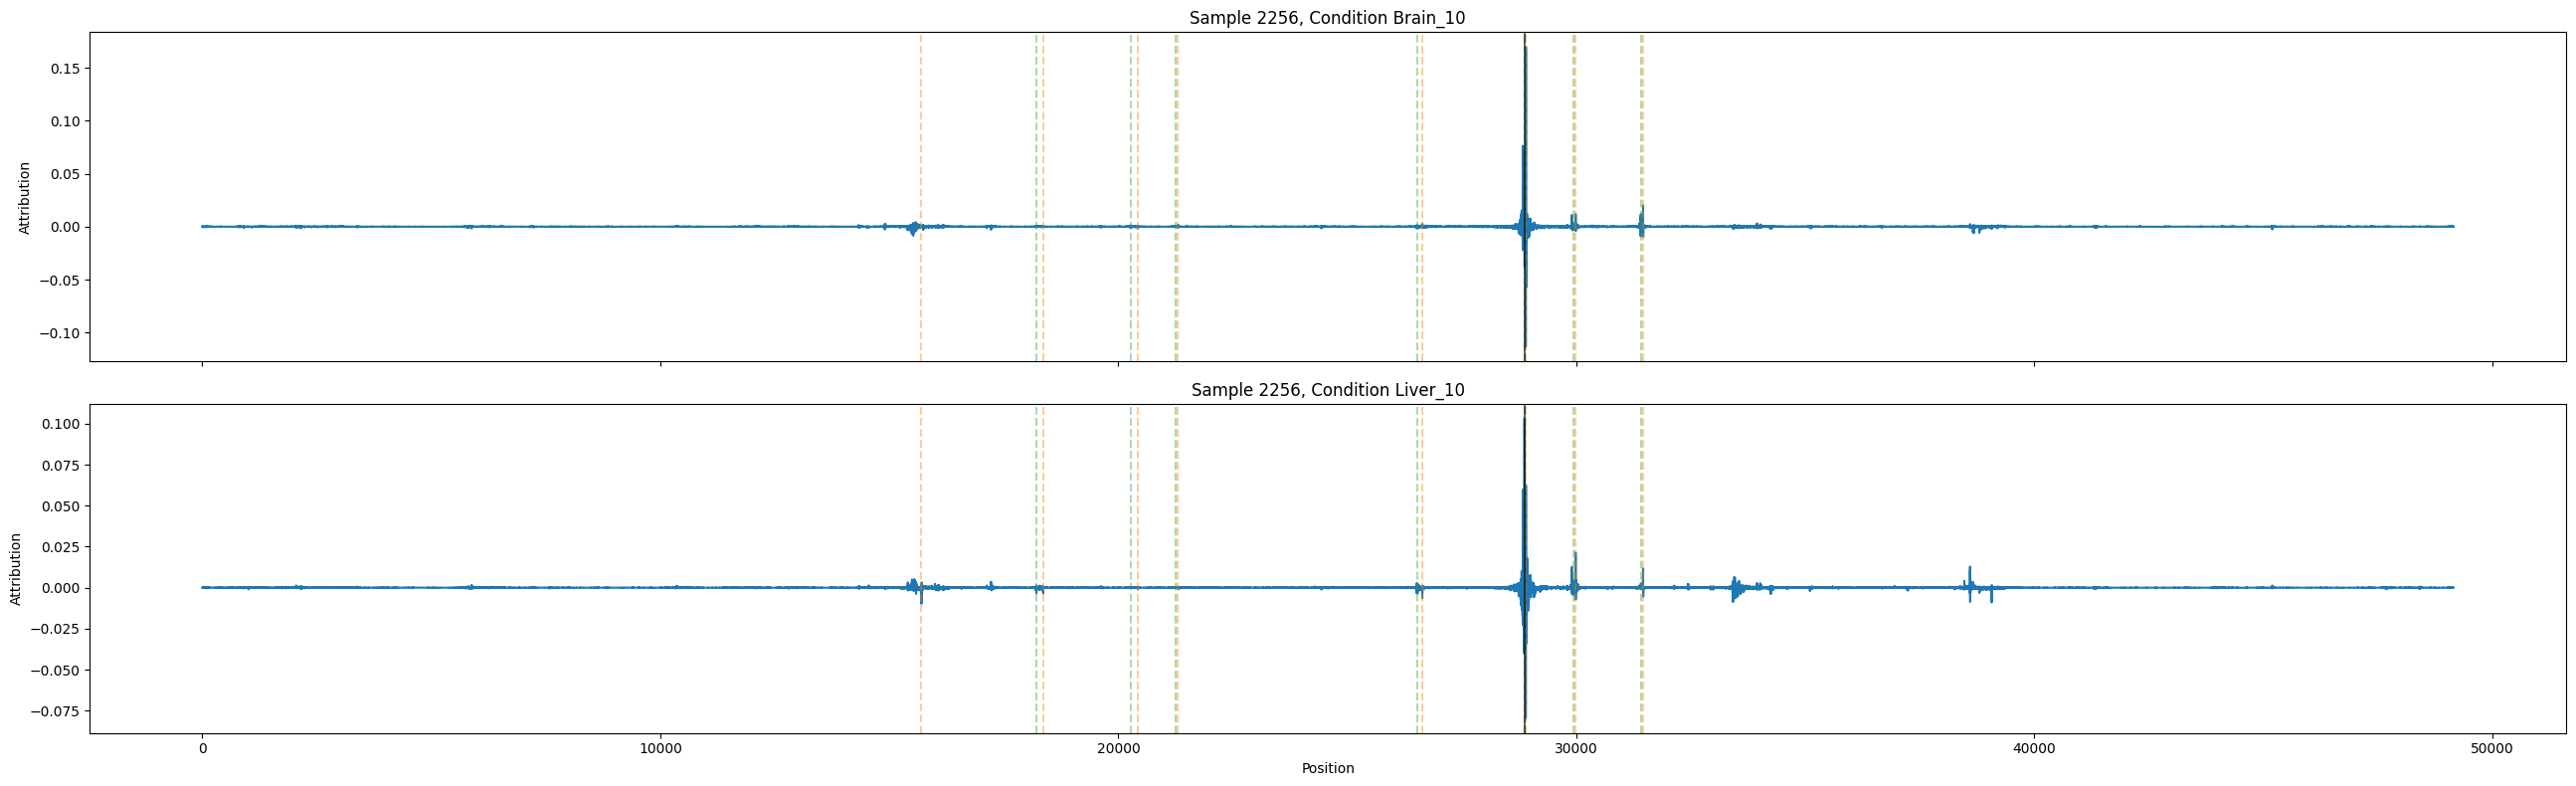

In [ ]:
import matplotlib.pyplot as plt

n_conds = len(grads_usage)
fig, axes = plt.subplots(n_conds, 1, figsize=(26, 4 * n_conds), sharex=True)

# If only one condition, axes is not a list
if n_conds == 1:
    axes = [axes]

for ax, (cond_, grads_) in zip(axes, grads_usage.items()):
    print(f"Gradients for condition {cond_}: {grads_.shape}")

    # Get gradients for the sequence in the batch
    grads_b = grads_[b]

    # Multiply gradients by input to get importance scores
    grads_b_importance = grads_b * onehot_tensor[b]
    grads_b_max = grads_b_importance.sum(dim=1)

    # Plot importance
    ax.plot(grads_b_max.detach().cpu().numpy())

    # Add vertical lines at splice site positions
    for k in range(4):
        site_positions = (splice_labels[b] == k).nonzero(as_tuple=True)[0]
        for pos in site_positions:
            ax.axvline(
                x=pos.item(),
                color=class_colors[k],
                linestyle='--',
                alpha=0.4
            )

    # Add selected site
    ax.axvline(
        x=p,
        color='black',
        linestyle='-',
        alpha=0.6,
        label='Selected site'
    )

    ax.set_title(f"Sample {rand_indx[b]}, Condition {cond_}")
    ax.set_ylabel("Attribution")

axes[-1].set_xlabel("Position")

plt.tight_layout()
plt.show()

In [85]:
# Make windows around the site for attribution plotting
w = 500
upstream_bins = torch.arange(p - w * 35, p, step=w)
downstream_bins = torch.arange(p + w, p + w * 35, step=w)
bins = torch.cat([upstream_bins, torch.tensor([p]), downstream_bins])
print(f"Bins around site: {bins.numpy()}")


Bins around site: [11372 11872 12372 12872 13372 13872 14372 14872 15372 15872 16372 16872
 17372 17872 18372 18872 19372 19872 20372 20872 21372 21872 22372 22872
 23372 23872 24372 24872 25372 25872 26372 26872 27372 27872 28372 28872
 29372 29872 30372 30872 31372 31872 32372 32872 33372 33872 34372 34872
 35372 35872 36372 36872 37372 37872 38372 38872 39372 39872 40372 40872
 41372 41872 42372 42872 43372 43872 44372 44872 45372 45872]


In [86]:
%reload_ext autoreload
%autoreload 2
from alphagenome_pytorch import AlphaGenome

# Plot for each condition
for c in selected_cond_indices:
    
    print(f"Plotting attributions for condition {cond_labels[c]} (index {c}) at position {p}")

    grads = grads_usage[cond_labels[c]]
    preds = preds_usage[cond_labels[c]]

    model.plot_sequence_logo(
        sequence=onehot_tensor,
        gradients=grads,
        batch_idx=b,
        positions=bins,
        splice_labels=splice_labels, # pass the full [B, S] label tensor
        window=w//2, # bp around each site
        mask_to_sequence=True,
        sharey=True,
        ylim=(-0.01, 0.01),
        save_path=f"plots/attr_usage_batch_{genome_id}_{rand_indx[b]}_{p}_{cond_labels[c]}.pdf",
        figsize=(24, 2)
    )

Plotting attributions for condition Brain_10 (index 9) at position 28872
Sequence logo saved to: plots/attr_usage_batch_mouse_GRCm38_2256_28872_Brain_10.pdf
Plotting attributions for condition Liver_10 (index 61) at position 28872
Sequence logo saved to: plots/attr_usage_batch_mouse_GRCm38_2256_28872_Liver_10.pdf


***

In [111]:
# Substract two conditions
cond1, cond2 = selected_cond_labels
grads_diff = grads_usage[cond1] - grads_usage[cond2]
model.plot_sequence_logo(
    sequence=onehot_tensor,
    gradients=grads_diff,
    batch_idx=b,
    positions=bins,
    splice_labels=splice_labels, # pass the full [B, S] label tensor
    window=w//2, # bp around each site
    mask_to_sequence=True,
    sharey=True,
    ylim=(-0.01, 0.01),
    save_path=f"plots/attr_usage_diff_batch_{genome_id}_{rand_indx[b]}_{p}_{cond1}_vs_{cond2}.pdf",
    figsize=(24, 2)
)

Sequence logo saved to: plots/attr_usage_diff_batch_mouse_GRCm38_2256_28872_Brain_10_vs_Liver_10.pdf


In [107]:
grads_usage[cond1][b][31400:31410, :]

tensor([[ 0.0026,  0.0024,  0.0023,  0.0043],
        [ 0.0031,  0.0003,  0.0036,  0.0055],
        [ 0.0023,  0.0012,  0.0022,  0.0037],
        [-0.0020,  0.0016,  0.0007,  0.0002],
        [-0.0089, -0.0046,  0.0075, -0.0015],
        [ 0.0086,  0.0035,  0.0034,  0.0049],
        [ 0.0046,  0.0048,  0.0118,  0.0053],
        [ 0.0027,  0.0028,  0.0073,  0.0043],
        [-0.0005,  0.0021,  0.0024,  0.0001],
        [ 0.0003,  0.0011,  0.0014,  0.0006]])

In [108]:
grads_usage[cond2][b][31400:31410, :]

tensor([[ 3.8712e-04,  1.0544e-04,  1.9917e-04,  3.0657e-04],
        [ 3.2721e-04, -5.0070e-05,  2.2220e-04,  3.0604e-04],
        [ 4.2191e-04, -2.8482e-04,  2.4943e-04,  1.8344e-06],
        [-5.0210e-04,  7.2093e-06, -1.8607e-04,  3.5030e-04],
        [-6.9265e-04, -4.4605e-04,  9.6737e-04,  2.1395e-04],
        [ 1.6692e-03,  6.5802e-04,  1.0378e-03,  9.0482e-04],
        [ 9.5858e-04,  9.7719e-04,  2.4620e-03,  1.4475e-03],
        [ 6.3323e-04,  7.8163e-04,  1.7537e-03,  1.1897e-03],
        [ 1.0468e-03,  5.3490e-04,  6.7143e-04,  5.7309e-04],
        [-2.0172e-04,  2.2081e-04,  3.0083e-04,  2.0252e-04]])

In [109]:
grads_diff[b][31400:31410, :]

tensor([[ 0.0022,  0.0023,  0.0021,  0.0040],
        [ 0.0028,  0.0003,  0.0034,  0.0052],
        [ 0.0019,  0.0015,  0.0020,  0.0037],
        [-0.0015,  0.0016,  0.0008, -0.0001],
        [-0.0082, -0.0042,  0.0065, -0.0017],
        [ 0.0069,  0.0028,  0.0023,  0.0040],
        [ 0.0036,  0.0039,  0.0094,  0.0038],
        [ 0.0020,  0.0020,  0.0055,  0.0031],
        [-0.0015,  0.0015,  0.0017, -0.0005],
        [ 0.0005,  0.0009,  0.0011,  0.0004]])